# Analysis of Training Patterns and Sports Injuries in Middle- and Long-Distance Runners

## Research Question

**Do training patterns differ between injury and non-injury observations?**

## Project Overview

This project analyzes daily training data from middle- and long-distance runners to investigate whether training patterns differ between observations with and without recorded injuries.

The analysis includes data exploration, descriptive statistics, data visualization, correlation analysis, and statistical hypothesis testing using Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Data Loading and Initial Exploration

In this section, the dataset is loaded into a Pandas DataFrame.

The basic structure of the dataset, the number of observations and variables, the number of athletes, data types, and missing values are then examined.

In [2]:
df = pd.read_excel("Daily_Injury_Clean.xlsx")

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

Dataset loaded successfully.
Shape of dataset: (42766, 74)


## 2. Initial Data Exploration

After loading the dataset, its basic structure is examined.

The number of observations and variables, the number of unique athletes, data types, and missing values are checked to understand the dataset before performing the main analysis.

In [3]:
print("\nFirst five rows:")
print(df.head())

print("\nNumber of rows and columns:")
print(df.shape)

print("\nNumber of athletes:")
print(df["Athlete ID"].nunique())

print("\nData information:")
df.info()

print("\nTotal number of missing values:")
print(df.isna().sum().sum())


First five rows:
   Unnamed: 0  nr. sessions  total km  km Z3-4  km Z5-T1-T2  km sprinting  \
0           0             1       5.8      0.0          0.6           1.2   
1           1             0       0.0      0.0          0.0           0.0   
2           2             1       0.0      0.0          0.0           0.0   
3           3             0       0.0      0.0          0.0           0.0   
4           4             1       0.0      0.0          0.0           0.0   

   strength training  hours alternative  perceived exertion  \
0                  0               0.00                0.11   
1                  0               0.00                0.00   
2                  1               0.00                0.10   
3                  0               0.00                0.00   
4                  0               1.08                0.08   

   perceived trainingSuccess  ...  km Z5-T1-T2.6  km sprinting.6  \
0                        0.0  ...            0.0             0.0   
1   

## 3. Injury Distribution

Before comparing training patterns, the distribution of injury and non-injury observations is examined.

This helps to understand how frequently injuries are recorded in the dataset and whether the two groups are balanced.

In [4]:
injury_counts = df["injury"].value_counts()

print("\nInjury distribution:")
print(injury_counts)

injury_percentages = (
    df["injury"].value_counts(normalize=True) * 100
)

print("\nInjury percentages:")
print(injury_percentages)


Injury distribution:
injury
0    42183
1      583
Name: count, dtype: int64

Injury percentages:
injury
0    98.636768
1     1.363232
Name: proportion, dtype: float64


In [5]:
injury_count = df["injury"].value_counts().sort_index()

injury_percentage = (
    df["injury"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

summary_table = pd.DataFrame({
    "Number of Observations": injury_count,
    "Percentage": injury_percentage.round(2)
})

summary_table.index = ["No Injury", "Injury"]

print("\nInjury Summary:")
print(summary_table)


Injury Summary:
           Number of Observations  Percentage
No Injury                   42183       98.64
Injury                        583        1.36


## 4. Injury Distribution Visualization

The distribution of injury and non-injury observations is visualized using a bar chart.

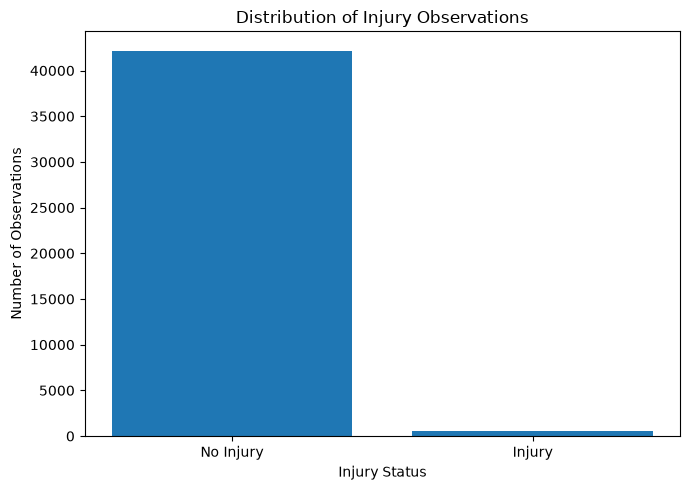

In [6]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Injury", "Injury"],
    [
        injury_counts.get(0, 0),
        injury_counts.get(1, 0)
    ]
)

plt.title("Distribution of Injury Observations")
plt.xlabel("Injury Status")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

## 5. Training Variables and Descriptive Statistics

The main training variables are selected for the analysis.

Descriptive statistics are then used to summarize the numerical variables, including their mean, standard deviation, minimum, maximum, and quartiles.

In [7]:
training_variables = [
    "nr. sessions",
    "total km",
    "km Z3-4",
    "km Z5-T1-T2",
    "km sprinting",
    "strength training",
    "hours alternative",
    "perceived exertion",
    "perceived trainingSuccess",
    "perceived recovery"
]

numeric_training_variables = [
    "nr. sessions",
    "total km",
    "km Z3-4",
    "km Z5-T1-T2",
    "km sprinting",
    "hours alternative",
    "perceived exertion",
    "perceived trainingSuccess",
    "perceived recovery"
]

print("\nDescriptive statistics:")

descriptive_statistics = df[training_variables].describe()

print(descriptive_statistics)


Descriptive statistics:
       nr. sessions      total km       km Z3-4   km Z5-T1-T2  km sprinting  \
count  42766.000000  42766.000000  42766.000000  42766.000000  42766.000000   
mean       0.829561      7.038187      0.691381      0.579930      0.073016   
std        0.580696      7.473216      2.317657      1.811938      0.483480   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        1.000000      6.000000      0.000000      0.000000      0.000000   
75%        1.000000     12.000000      0.000000      0.000000      0.000000   
max        2.000000     55.900000     42.200000     48.000000     40.000000   

       strength training  hours alternative  perceived exertion  \
count       42766.000000       42766.000000        42766.000000   
mean            0.116237           0.163492            0.250471   
std             0.326010           0.549664            0.25459

## 6. Comparison of Training Patterns by Injury Status

The mean values of the selected training variables are compared between injury and non-injury observations.

This comparison provides an initial overview of how training patterns differ between the two groups.

In [8]:
injury_summary = (
    df.groupby("injury")[training_variables]
    .mean()
)

print("\nMean training variables by injury status:")
print(injury_summary)


Mean training variables by injury status:
        nr. sessions  total km  km Z3-4  km Z5-T1-T2  km sprinting  \
injury                                                               
0           0.827916  7.024178  0.69120     0.575692      0.072356   
1           0.948542  8.051801  0.70446     0.886621      0.120755   

        strength training  hours alternative  perceived exertion  \
injury                                                             
0                0.116018           0.164080            0.249282   
1                0.132075           0.120892            0.336484   

        perceived trainingSuccess  perceived recovery  
injury                                                 
0                        0.350989            0.197895  
1                        0.460789            0.248250  


## 7. Visual Comparison of Training Variables

Bar charts are used to visually compare the mean training variables between injury and non-injury observations.

Both the complete set of training variables and selected variables are visualized.

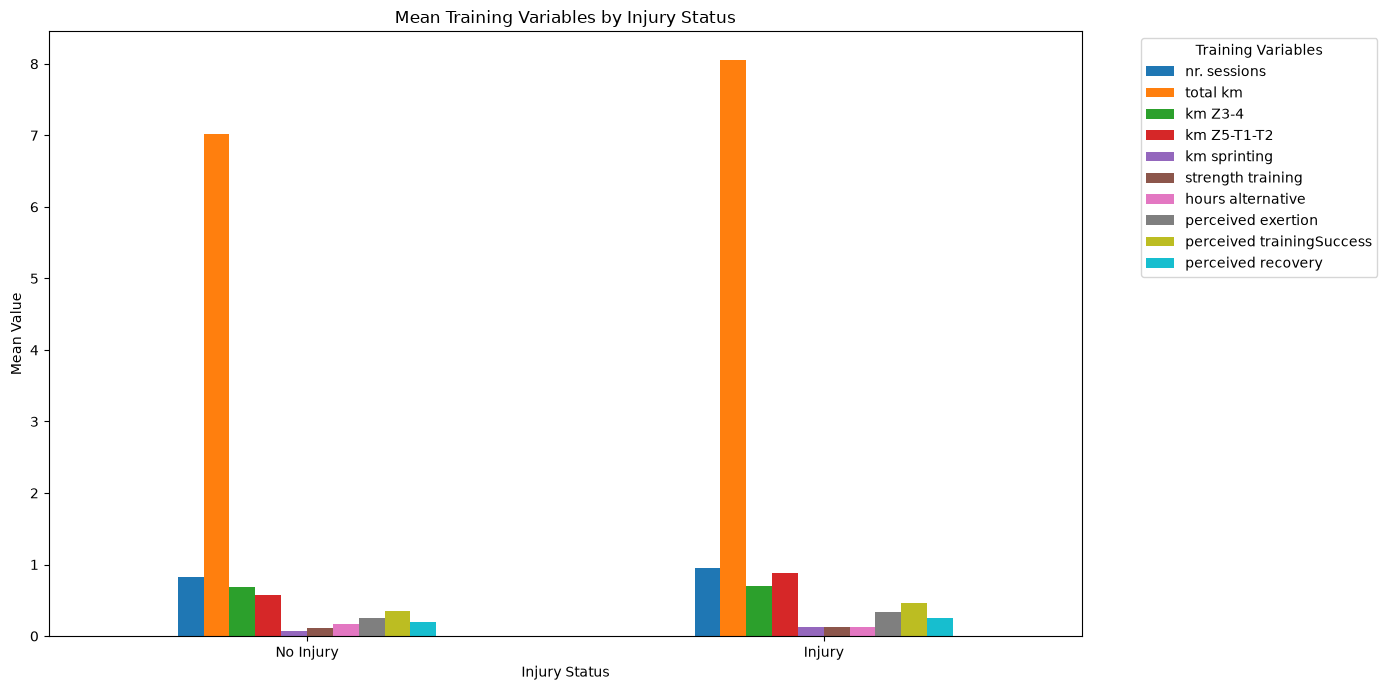

In [9]:
injury_summary.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Mean Training Variables by Injury Status")
plt.xlabel("Injury Status")
plt.ylabel("Mean Value")

plt.xticks(
    [0, 1],
    ["No Injury", "Injury"],
    rotation=0
)

plt.legend(
    title="Training Variables",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

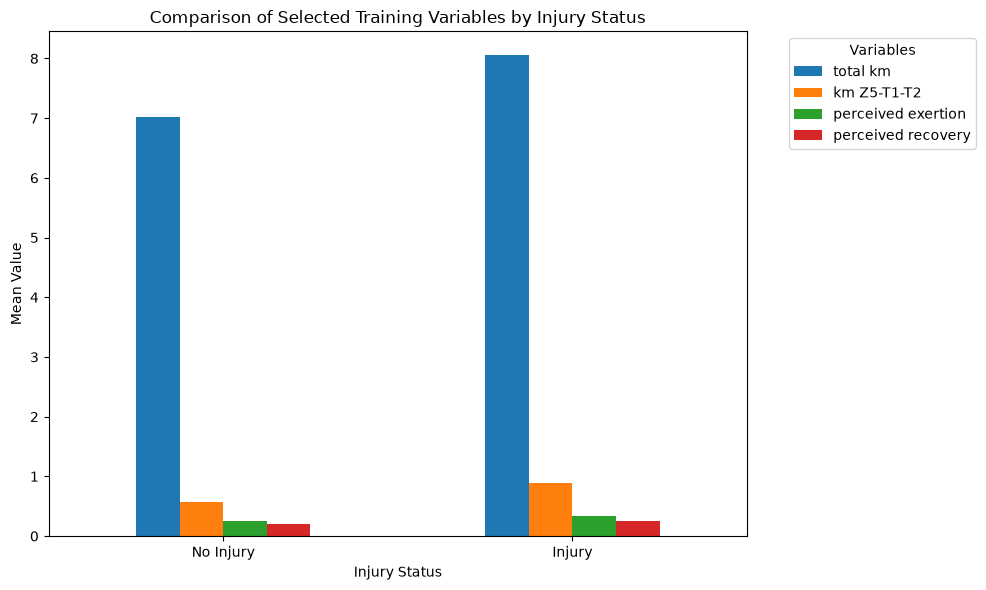

In [10]:
injury_summary[
    [
        "total km",
        "km Z5-T1-T2",
        "perceived exertion",
        "perceived recovery"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Comparison of Selected Training Variables by Injury Status"
)

plt.xlabel("Injury Status")
plt.ylabel("Mean Value")

plt.xticks(
    [0, 1],
    ["No Injury", "Injury"],
    rotation=0
)

plt.legend(
    title="Variables",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 8. Distribution of Training Variables

Boxplots are used to compare the distributions of selected training variables between injury and non-injury observations.

Boxplots provide information about the median, spread, and potential outliers of the data.

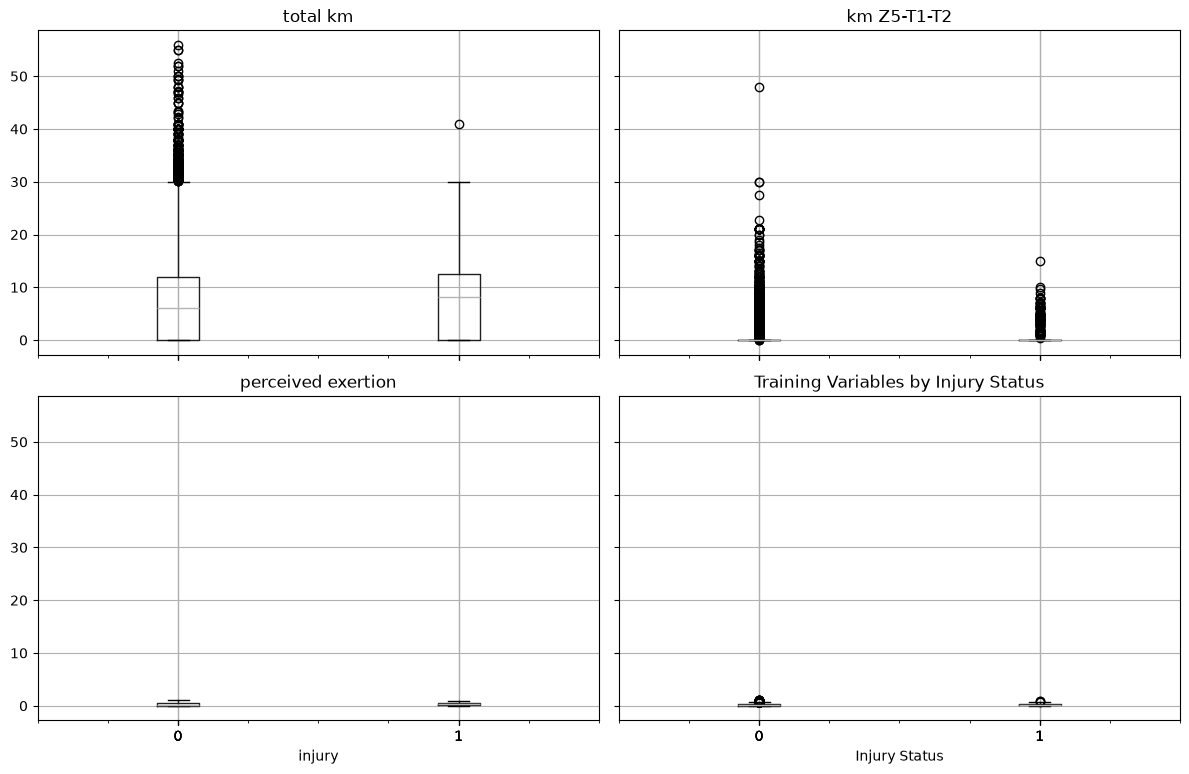

In [11]:
df.boxplot(
    column=[
        "total km",
        "km Z5-T1-T2",
        "perceived exertion",
        "perceived recovery"
    ],
    by="injury",
    figsize=(12, 8)
)

plt.suptitle("")
plt.title("Training Variables by Injury Status")
plt.xlabel("Injury Status")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

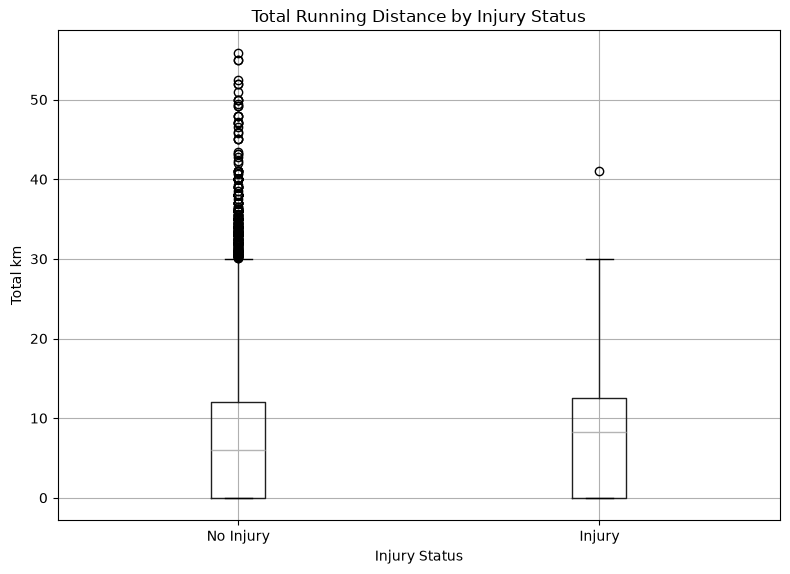

In [12]:
df.boxplot(
    column="total km",
    by="injury",
    figsize=(8, 6)
)

plt.suptitle("")
plt.title("Total Running Distance by Injury Status")
plt.xlabel("Injury Status")
plt.ylabel("Total km")

plt.xticks(
    [1, 2],
    ["No Injury", "Injury"]
)

plt.tight_layout()
plt.show()

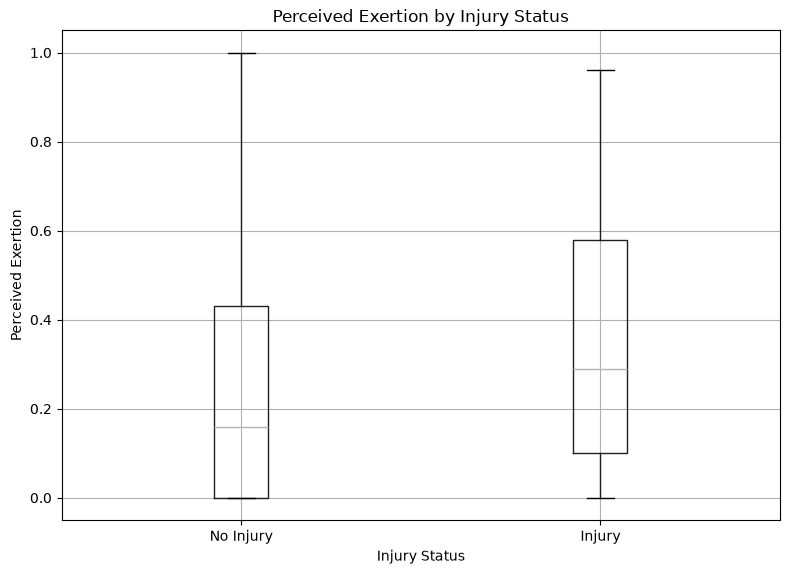

In [13]:
df.boxplot(
    column="perceived exertion",
    by="injury",
    figsize=(8, 6)
)

plt.suptitle("")
plt.title("Perceived Exertion by Injury Status")
plt.xlabel("Injury Status")
plt.ylabel("Perceived Exertion")

plt.xticks(
    [1, 2],
    ["No Injury", "Injury"]
)

plt.tight_layout()
plt.show()

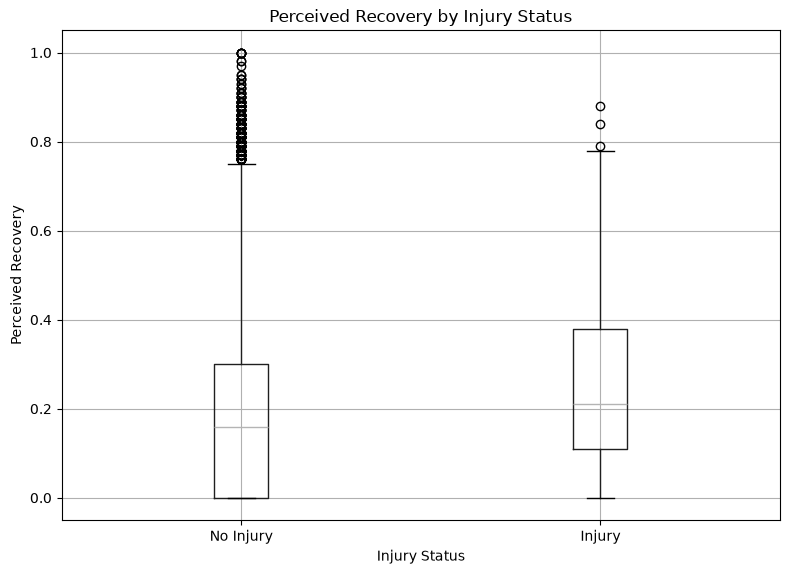

In [14]:
df.boxplot(
    column="perceived recovery",
    by="injury",
    figsize=(8, 6)
)

plt.suptitle("")
plt.title("Perceived Recovery by Injury Status")
plt.xlabel("Injury Status")
plt.ylabel("Perceived Recovery")

plt.xticks(
    [1, 2],
    ["No Injury", "Injury"]
)

plt.tight_layout()
plt.show()

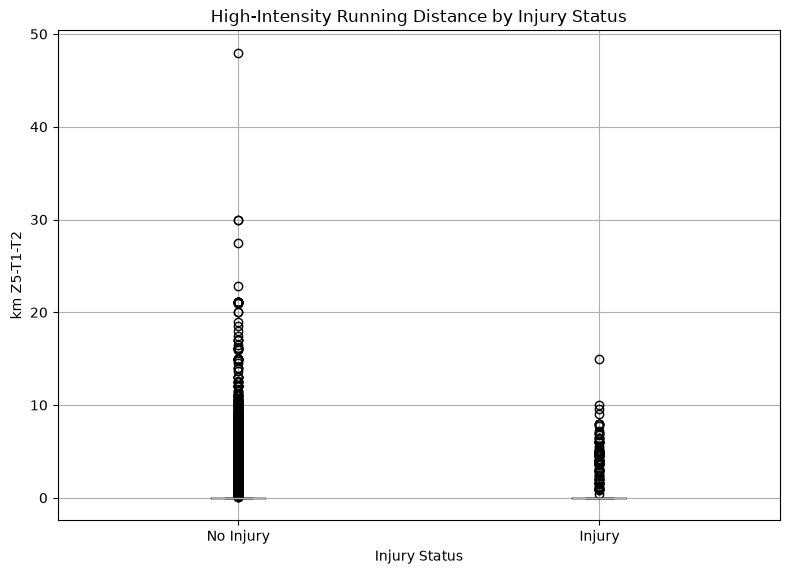

In [15]:
df.boxplot(
    column="km Z5-T1-T2",
    by="injury",
    figsize=(8, 6)
)

plt.suptitle("")
plt.title("High-Intensity Running Distance by Injury Status")
plt.xlabel("Injury Status")
plt.ylabel("km Z5-T1-T2")

plt.xticks(
    [1, 2],
    ["No Injury", "Injury"]
)

plt.tight_layout()
plt.show()

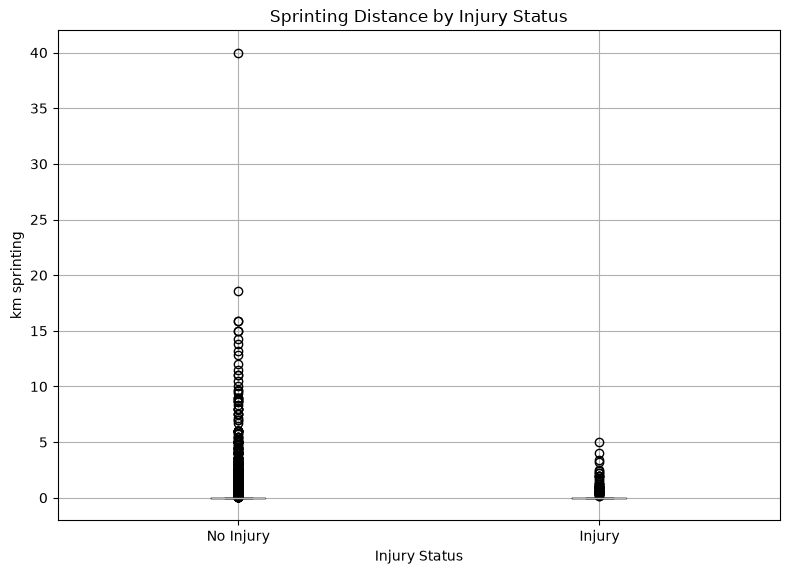

In [16]:
df.boxplot(
    column="km sprinting",
    by="injury",
    figsize=(8, 6)
)

plt.suptitle("")
plt.title("Sprinting Distance by Injury Status")
plt.xlabel("Injury Status")
plt.ylabel("km sprinting")

plt.xticks(
    [1, 2],
    ["No Injury", "Injury"]
)

plt.tight_layout()
plt.show()

## 9. Statistical Testing

Statistical hypothesis tests are used to examine whether the observed differences between injury and non-injury observations are statistically significant.

The Mann–Whitney U test is used because it compares the distributions of a numerical variable between two independent groups.

In [17]:
no_injury = df[df["injury"] == 0]["total km"]

injury = df[df["injury"] == 1]["total km"]

print("\nNumber of observations:")
print("No Injury:", len(no_injury))
print("Injury:", len(injury))


Number of observations:
No Injury: 42183
Injury: 583


## 10. Mann–Whitney U Test for Total Running Distance

The Mann–Whitney U test is first applied to total running distance (`total km`).

The null hypothesis is that the distributions of total running distance are the same in the injury and non-injury groups.

A p-value below 0.05 is considered statistically significant for this exploratory analysis.

In [18]:
statistic, p_value = stats.mannwhitneyu(
    no_injury,
    injury,
    alternative="two-sided"
)

print("\nMann-Whitney U Test for Total km:")
print("U statistic:", statistic)
print("p-value:", p_value)


Mann-Whitney U Test for Total km:
U statistic: 11031698.5
p-value: 9.830794865624827e-06


## 11. Mann–Whitney U Tests for Multiple Training Variables

The Mann–Whitney U test is repeated for the selected numerical training variables.

For each variable, the U statistic and p-value are recorded in a summary table.

These tests are exploratory, and the use of multiple statistical tests should be considered when interpreting the results.

In [19]:
variables = [
    "nr. sessions",
    "total km",
    "km Z3-4",
    "km Z5-T1-T2",
    "km sprinting",
    "hours alternative",
    "perceived exertion",
    "perceived trainingSuccess",
    "perceived recovery"
]

results = []

for variable in variables:

    no_injury = df[df["injury"] == 0][variable]

    injury = df[df["injury"] == 1][variable]

    statistic, p_value = stats.mannwhitneyu(
        no_injury,
        injury,
        alternative="two-sided"
    )

    results.append({
        "Variable": variable,
        "U statistic": statistic,
        "p-value": p_value
    })


test_results = pd.DataFrame(results)

print("\nMann-Whitney U Test Results:")
print(test_results)


Mann-Whitney U Test Results:
                    Variable  U statistic       p-value
0               nr. sessions   11005401.0  3.047362e-07
1                   total km   11031698.5  9.830795e-06
2                    km Z3-4   12312454.5  9.201840e-01
3                km Z5-T1-T2   11436522.5  8.748183e-07
4               km sprinting   11848074.5  9.417934e-04
5          hours alternative   12556656.5  1.233992e-01
6         perceived exertion   10037510.5  1.092864e-14
7  perceived trainingSuccess   10262569.0  2.720184e-13
8         perceived recovery   10332508.5  1.805587e-11


In [20]:
test_results["Significant"] = (
    test_results["p-value"] < 0.05
)

test_results = test_results.sort_values(
    "p-value"
)

print("\nSorted Statistical Test Results:")
print(test_results)


Sorted Statistical Test Results:
                    Variable  U statistic       p-value  Significant
6         perceived exertion   10037510.5  1.092864e-14         True
7  perceived trainingSuccess   10262569.0  2.720184e-13         True
8         perceived recovery   10332508.5  1.805587e-11         True
0               nr. sessions   11005401.0  3.047362e-07         True
3                km Z5-T1-T2   11436522.5  8.748183e-07         True
1                   total km   11031698.5  9.830795e-06         True
4               km sprinting   11848074.5  9.417934e-04         True
5          hours alternative   12556656.5  1.233992e-01        False
2                    km Z3-4   12312454.5  9.201840e-01        False


## 12. Statistical Significance Visualization

The p-values from the Mann–Whitney U tests are visualized to make it easier to compare the statistical results across training variables.

The horizontal reference line represents the 0.05 significance level.

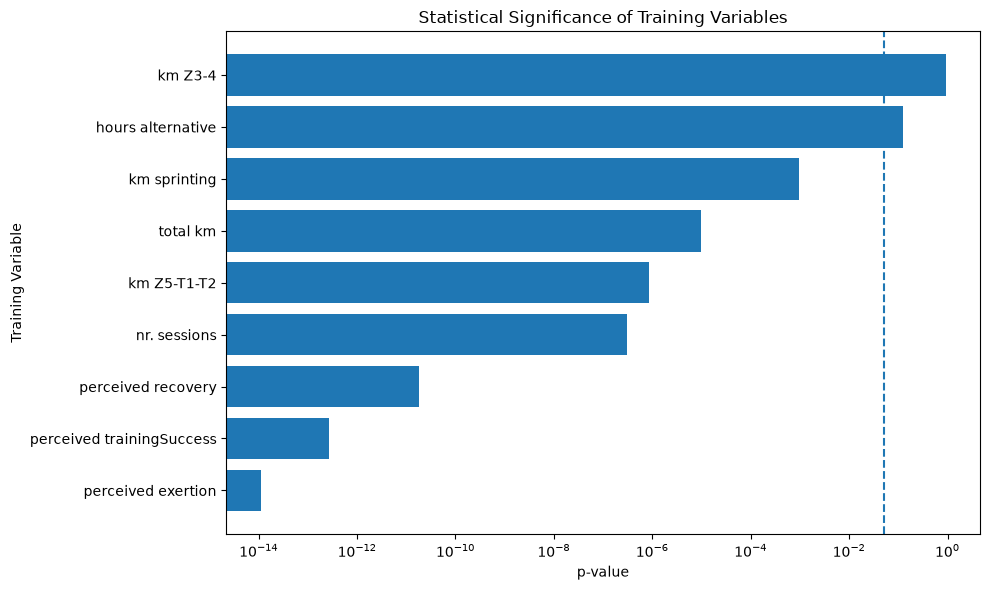

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    test_results["Variable"],
    test_results["p-value"]
)

plt.axvline(
    0.05,
    linestyle="--"
)

plt.xscale("log")

plt.xlabel("p-value")
plt.ylabel("Training Variable")

plt.title(
    "Statistical Significance of Training Variables"
)

plt.tight_layout()
plt.show()

## 13. Correlation Analysis

The relationship between total running distance and perceived exertion is examined using Spearman correlation.

Spearman correlation measures the strength and direction of a monotonic relationship between two numerical variables.

The correlation coefficient ranges from -1 to +1.

In [22]:
correlation = df["total km"].corr(
    df["perceived exertion"],
    method="spearman"
)

print("\nSpearman correlation:")
print(correlation)


Spearman correlation:
0.47351763663331764


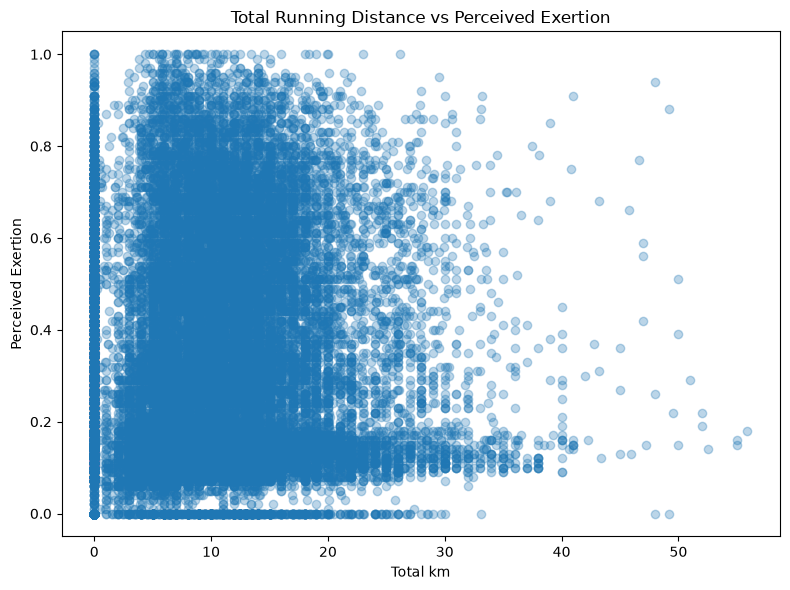

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["total km"],
    df["perceived exertion"],
    alpha=0.3
)

plt.title(
    "Total Running Distance vs Perceived Exertion"
)

plt.xlabel("Total km")
plt.ylabel("Perceived Exertion")

plt.tight_layout()
plt.show()

## 14. Strength Training and Injury

The relationship between strength training and injury status is examined using a contingency table and a chi-square test.

The contingency table shows the number of observations for each combination of injury status and strength training value.

In [24]:
strength_by_injury = pd.crosstab(
    df["injury"],
    df["strength training"]
)

print("\nStrength Training by Injury Status:")
print(strength_by_injury)


Strength Training by Injury Status:
strength training      0     1   2
injury                            
0                  37365  4742  76
1                    506    77   0


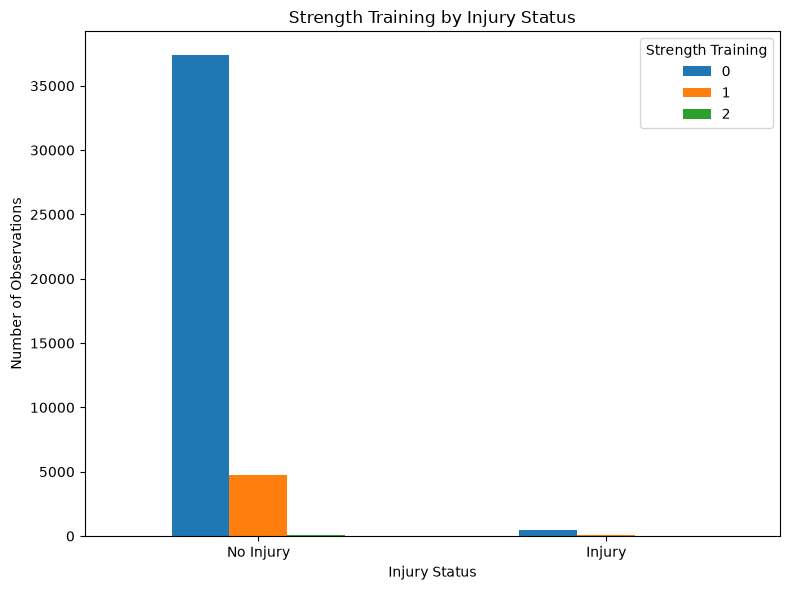

In [25]:
strength_by_injury.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title(
    "Strength Training by Injury Status"
)

plt.xlabel("Injury Status")
plt.ylabel("Number of Observations")

plt.xticks(
    [0, 1],
    ["No Injury", "Injury"],
    rotation=0
)

plt.legend(
    title="Strength Training"
)

plt.tight_layout()
plt.show()

## 15. Chi-Square Test

A chi-square test of independence is used to examine whether injury status and strength training are statistically associated.

A p-value below 0.05 is considered statistically significant for this exploratory analysis.

In [26]:
contingency_table = pd.crosstab(
    df["injury"],
    df["strength training"]
)

chi2, chi_p_value, degrees_of_freedom, expected = (
    stats.chi2_contingency(contingency_table)
)

print("\nChi-square Test:")
print("Chi-square statistic:", chi2)
print("p-value:", chi_p_value)
print("Degrees of freedom:", degrees_of_freedom)


Chi-square Test:
Chi-square statistic: 3.230087913362551
p-value: 0.19888192805915486
Degrees of freedom: 2


## 16. Perceived Training Success and Recovery

Perceived training success and perceived recovery are compared between injury and non-injury observations.

The mean values are visualized separately to make the differences between the two groups easier to examine.

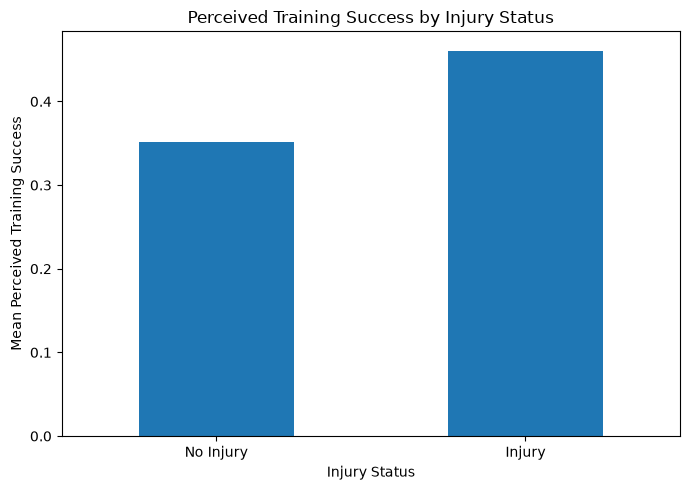

In [27]:
training_success_summary = (
    df.groupby("injury")["perceived trainingSuccess"]
    .mean()
)

training_success_summary.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title(
    "Perceived Training Success by Injury Status"
)

plt.xlabel("Injury Status")
plt.ylabel("Mean Perceived Training Success")

plt.xticks(
    [0, 1],
    ["No Injury", "Injury"],
    rotation=0
)

plt.tight_layout()
plt.show()

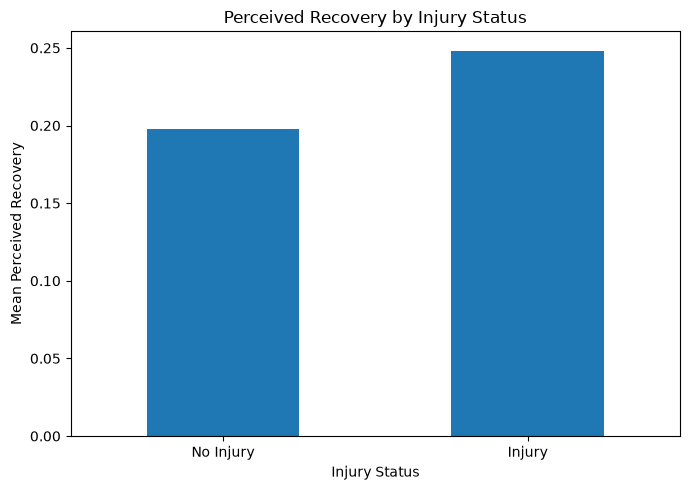

In [28]:
recovery_summary = (
    df.groupby("injury")["perceived recovery"]
    .mean()
)

recovery_summary.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title(
    "Perceived Recovery by Injury Status"
)

plt.xlabel("Injury Status")
plt.ylabel("Mean Perceived Recovery")

plt.xticks(
    [0, 1],
    ["No Injury", "Injury"],
    rotation=0
)

plt.tight_layout()
plt.show()

## 17. Results

The statistical results are summarized to identify which training variables show statistically significant differences between injury and non-injury observations.

A significance level of 0.05 is used for this exploratory analysis.

In [29]:
print("\nSUMMARY OF STATISTICAL TESTS")
print("=" * 50)

for _, row in test_results.iterrows():

    if row["Significant"]:
        print(
            row["Variable"],
            "→ Significant"
        )

    else:
        print(
            row["Variable"],
            "→ Not Significant"
        )


SUMMARY OF STATISTICAL TESTS
perceived exertion → Significant
perceived trainingSuccess → Significant
perceived recovery → Significant
nr. sessions → Significant
km Z5-T1-T2 → Significant
total km → Significant
km sprinting → Significant
hours alternative → Not Significant
km Z3-4 → Not Significant


## 18. Final Project Summary

The final summary reports the total number of observations, the number of athletes, and the number of injury and non-injury observations.

The statistically significant and non-significant training variables are also summarized.

In [30]:
print("\nFINAL PROJECT SUMMARY")
print("=" * 50)

print(
    "Total observations:",
    len(df)
)

print(
    "Number of athletes:",
    df["Athlete ID"].nunique()
)

print(
    "Injury observations:",
    (df["injury"] == 1).sum()
)

print(
    "Non-injury observations:",
    (df["injury"] == 0).sum()
)

print(
    "\nStatistically significant variables (p < 0.05):"
)

for _, row in test_results.iterrows():

    if row["Significant"]:
        print(
            "-",
            row["Variable"]
        )

print(
    "\nVariables without statistical significance:"
)

for _, row in test_results.iterrows():

    if not row["Significant"]:
        print(
            "-",
            row["Variable"]
        )


FINAL PROJECT SUMMARY
Total observations: 42766
Number of athletes: 74
Injury observations: 583
Non-injury observations: 42183

Statistically significant variables (p < 0.05):
- perceived exertion
- perceived trainingSuccess
- perceived recovery
- nr. sessions
- km Z5-T1-T2
- total km
- km sprinting

Variables without statistical significance:
- hours alternative
- km Z3-4


## 19. Limitations

Several limitations should be considered when interpreting the results.

- The dataset contains repeated observations from the same athletes, so the observations cannot be treated as fully independent.
- The number of injury observations is much smaller than the number of non-injury observations.
- Multiple statistical tests were performed, which increases the possibility of obtaining statistically significant results by chance.
- The analysis identifies differences and associations but does not establish causal relationships.
- The statistical analysis should therefore be interpreted as exploratory.

In [31]:
print("\nIMPORTANT INTERPRETATION NOTE")
print("=" * 50)

print(
    "The statistical results show differences or associations "
    "between injury and non-injury observations."
)

print(
    "They do not establish causal relationships."
)

print(
    "The dataset contains repeated observations from the same "
    "athletes, so the statistical results should be interpreted "
    "as exploratory."
)

print(
    "The injury and non-injury observations are also highly "
    "imbalanced."
)

print(
    "Multiple statistical tests were performed, so the possibility "
    "of multiple-testing effects should also be considered."
)


IMPORTANT INTERPRETATION NOTE
The statistical results show differences or associations between injury and non-injury observations.
They do not establish causal relationships.
The dataset contains repeated observations from the same athletes, so the statistical results should be interpreted as exploratory.
The injury and non-injury observations are also highly imbalanced.
Multiple statistical tests were performed, so the possibility of multiple-testing effects should also be considered.
